Day 7 — Task

Implement Logistic Regression From Scratch

Objective

Build a binary classification model using:

linear model

sigmoid function

cross-entropy loss

gradient descent

You must implement the entire training pipeline yourself.

Problem Statement

You are given data about students:

hours studied

attendance percentage

Your task is to predict whether the student will:

Label	Meaning
0	Fail
1	Pass
Dataset
import numpy as np

X = np.array([
    [2, 50],
    [4, 60],
    [6, 65],
    [8, 80],
    [1, 30],
    [3, 40],
    [7, 85],
    [5, 70]
], dtype=float)

y = np.array([0,0,1,1,0,0,1,1], dtype=float)
Step 1 — Normalize Features

Apply min-max normalization:

X_norm = (X - X.min(axis=0)) / (X.max(axis=0) - X.min(axis=0))
Step 2 — Initialize Parameters

You have 2 features, so you need:

2 weights

1 bias

w = np.zeros(2)
b = 0
learning_rate = 0.1
Step 3 — Implement Sigmoid Function
def sigmoid(z):
    return 1 / (1 + np.exp(-z))
Step 4 — Training Loop

Train the model using gradient descent.

Inside a loop of 5000 iterations:

Compute linear score
𝑧
=
𝑋
𝑤
+
𝑏
z=Xw+b
z = np.dot(X_norm, w) + b
Convert score to probability
y_pred = sigmoid(z)
Compute cross-entropy loss
𝐿
=
−
1
𝑛
∑
(
𝑦
ln
⁡
(
𝑝
)
+
(
1
−
𝑦
)
ln
⁡
(
1
−
𝑝
)
)
L=−
n
1
	​

∑(yln(p)+(1−y)ln(1−p))
loss = -np.mean(
    y * np.log(y_pred + 1e-9) +
    (1 - y) * np.log(1 - y_pred + 1e-9)
)
Compute gradients
dw = (1 / len(X_norm)) * np.dot(X_norm.T, (y_pred - y))
db = (1 / len(X_norm)) * np.sum(y_pred - y)
Update parameters
w -= learning_rate * dw
b -= learning_rate * db
Print training progress

Every 500 iterations print:

print(f"Iteration {i}, Loss: {loss}")
Step 5 — Convert Probabilities to Classes

After training:

predicted_classes = (y_pred >= 0.5).astype(int)
Step 6 — Compute Accuracy
accuracy = np.mean(predicted_classes == y)
print("Accuracy:", accuracy)
Expected Output

You should see:

loss decreasing

predicted classes close to actual labels

accuracy close to 1.0

What You Are Practicing

This task combines everything you learned:

Concept	Used
Normalization	✓
Vectorization	✓
Sigmoid	✓
Cross-entropy loss	✓
Gradient descent	✓
Classification threshold	✓
Day 7 Report

After completing the task, report:

Day 7 update

• What I studied:
• What I built:
• What I understood well:
• What confused me:
• Time spent:

Also include:

Final weights:
Final bias:
Final loss:
Accuracy:

Loss: 0.6931471785599453
Loss: 0.27453450232380777
Loss: 0.19923466444802357
Loss: 0.1655725454168352
Loss: 0.1454488471918211
Loss: 0.13158566991133525
Loss: 0.12120537640084028
Loss: 0.11299870552217028
Loss: 0.10625954545364868
Loss: 0.10056952464988421
Final weights: [7.86497937 5.89271133]
Final bias: -7.324545808261627
Accuracy: 1.0


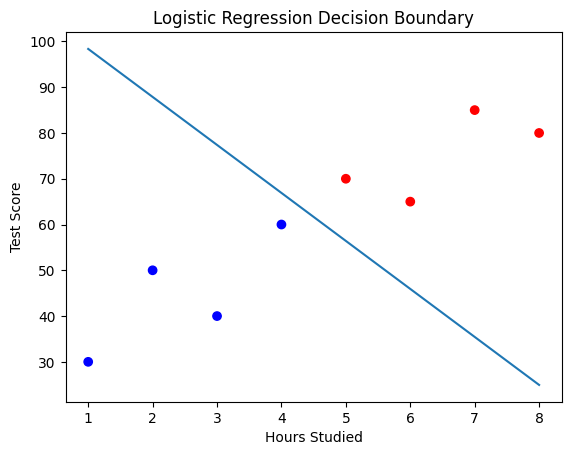

In [5]:
import matplotlib.pyplot as plt
import numpy as np 

X = np.array([
    [2, 50],
    [4, 60],
    [6, 65],
    [8, 80],
    [1, 30],
    [3, 40],
    [7, 85],
    [5, 70]
], dtype=float)

y = np.array([0,0,1,1,0,0,1,1], dtype=float)

X_norm = (X - X.min(axis=0)) / (X.max(axis=0) - X.min(axis=0))

w = np.zeros(2)
b = 0
learning_rate = 0.1

def sigmoid(z):
    return 1/(1 + np.exp(-z))



for i in range(5000):
    z = np.dot(X_norm, w) + b
    y_pred = sigmoid(z)
    loss = -np.mean(y * np.log(y_pred + 1e-9) + (1 - y) * np.log(1 - y_pred + 1e-9))

    dw = np.dot(X_norm.T, (y_pred - y)) / len(X_norm)
    db = np.mean(y_pred - y)

    w -= learning_rate * dw
    b -= learning_rate * db

    if i % 500 == 0:
        print("Loss:", loss)
print("Final weights:", w)
print("Final bias:", b)
accuracy = np.mean((y_pred >= 0.5) == y)
print("Accuracy:", accuracy)

plt.scatter(X[:, 0], X[:, 1], c=y, cmap='bwr')
x_vals = np.linspace(X[:,0].min(), X[:,0].max(), 100)

x_vals_norm = (x_vals - X[:,0].min()) / (X[:,0].max() - X[:,0].min())

y_norm = -(w[0]*x_vals_norm + b) / w[1]

y_vals = y_norm * (X[:,1].max() - X[:,1].min()) + X[:,1].min()

plt.plot(x_vals, y_vals)
plt.xlabel('Hours Studied')
plt.ylabel('Test Score')
plt.title('Logistic Regression Decision Boundary')
plt.show()